# SAM3

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## 1) 허깅페이스 로그인

In [2]:
import os

from huggingface_hub import login

login(token=os.getenv('HUGGINGFACE_TOKEN'))

## 2) 허깅페이스 다운로드

In [4]:
from huggingface_hub import hf_hub_download

from lib.utils.path import data_path

hf_hub_download(
    repo_id='facebook/sam3',
    filename='sam3.pt',
    local_dir=data_path() / 'models',
    token=os.getenv('HUGGINGFACE_TOKEN'),
)

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

'c:\\Workspaces\\model_lab\\data\\models\\sam3.pt'

In [7]:
from ultralytics.models.sam import SAM3SemanticPredictor

from lib.utils.path import model_path

overrides = {
    'conf': 0.25,
    'task': 'segment',
    'mode': 'predict',
    'model': model_path('sam3.pt'),
    'half': True,
    'save': True,
}

predictor = SAM3SemanticPredictor(overrides=overrides)

In [10]:
predictor.set_image(data_path() / 'images' / 'bus.jpg')

WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]


In [11]:
preds = predictor(text=['a person'])


image 1/1 c:\Workspaces\model_lab\data\images\bus.jpg: 644x644 6 a persons, 465.4ms
Speed: 3.9ms preprocess, 465.4ms inference, 39.8ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Workspaces\model_lab\runs\segment\predict


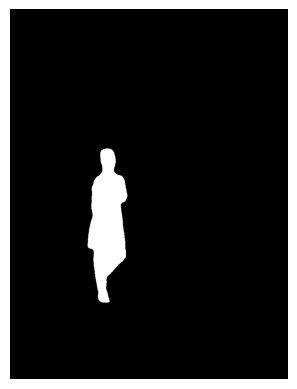

In [12]:
import matplotlib.pyplot as plt

pred = preds[0]

idx = 0

plt.imshow(pred.masks.data[idx].to('cpu'), cmap='gray')
plt.axis('off')
plt.show()

In [13]:
preds = predictor(text=['person', 'bus'])


image 1/1 c:\Workspaces\model_lab\data\images\bus.jpg: 644x644 6 persons, 1 bus, 506.5ms
Speed: 5.2ms preprocess, 506.5ms inference, 1.7ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Workspaces\model_lab\runs\segment\predict


In [14]:
# 예측하기 3 - 묘사로 추출
results = predictor(text=['person with red cloth', 'person with blue cloth'])


image 1/1 c:\Workspaces\model_lab\data\images\bus.jpg: 644x644 2 person with red cloths, 2 person with blue cloths, 321.4ms
Speed: 5.2ms preprocess, 321.4ms inference, 2.1ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Workspaces\model_lab\runs\segment\predict
